<a href="https://colab.research.google.com/github/txcagla/membership-inference-attacks-and-defense-mechanisms/blob/main/capstone_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MEMBERSHIP INFERENCE ATTACKS AND DEFENSE MECHANISMS ON CNN ARHITECTURE

LIBRARIES AND IMPORTS

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Project directory
save_path = '/content/drive/MyDrive/CapstoneProject2'

if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"The folder has been created: {save_path}")

The folder has been created: /content/drive/MyDrive/CapstoneProject2


Installation of Necessary Libraries

In [3]:
# PyTorch ve torchvision (CNN modeli ve dataset için)
!pip install torch torchvision

# Differential Privacy için Opacus
# Facebook/Meta tarafından geliştirilmiş, Differential Privacy (DP) uygulamak için özel olarak tasarlanmış bir kütüphane.
# Gradient clipping ve noise ekleme gibi işlemleri otomatik yapar
!pip install opacus

# Scikit-learn (Random Forest attack modeli ve metrikler için)
!pip install scikit-learn

# Ek yardımcı kütüphaneler
!pip install matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 13.1 MB/s eta 0:00:00


Importing Libraries

In [4]:
# Hedef model (CNN) ve CIFAR-10 veri seti için
import torch
import torchvision

# Veri ön işleme (normalizasyon, tensör dönüşümü, veri artırma - augmentation)
import torchvision.transforms as transforms

# CNN katmanlarını (Conv2d, Pooling, Fully Connected) ve aktivasyon fonksiyonlarını (ReLU, Softmax) tanımlamak için
import torch.nn as nn
import torch.nn.functional as F

# Optimizasyon algoritmaları (SGD, Adam) - DP ve KD için kritik
import torch.optim as optim

# DataLoader: CIFAR-10'u batch'ler halinde modele beslemek için
# random_split: Eğitim, validasyon ve shadow modeller için eğitim-alt kümeleri oluşturmak amacıyla kullanılacak.
from torch.utils.data import DataLoader, random_split

# Differential Privacy (Opacus): Gardient clipping, noise ekleme, privacy budget hesaplama
from opacus import PrivacyEngine

# RandomForestClassifier: Shadow model-based membership inference attack'te kullanılacak asıl saldırı modeli.
# Inputu: Shadow modellerin çıktı vektörleri (örn. 10 sınıflı CIFAR-10 için 10 olasılık)
# Outputu: Üye mi/Değil mi(binary classification)
from sklearn.ensemble import RandomForestClassifier

# Metriklerin hesaplanması
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Progress bar: Eğitim döngülerinde ilerleme çubuğu (özellikle KD'de öğretmen-öğrenci eğitimi ve shadow modellerin eğitimi uzun sürebilir)
from tqdm import tqdm

# Görselleştirme için matplotlib: Karşılaştırmalı grafikler (3 savunma yöntemi için yan yana ROC eğrileri, accuracy bar plotları)
import matplotlib.pyplot as plt

# NumPy: Tensor'ları numpy array'e çevirmek için (Random Forest, numpy girdisi bekler)
import numpy as np

Device Control and Speedup Settings

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {device}")

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

Device used: cpu


Seed adjustment for reproducibility

In [6]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # CNN operasyonlarını deterministik hale getirme
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seed {seed} was successfully configured and cuDNN was put into deterministic mode.")

set_seed(42)

Seed 42 was successfully configured and cuDNN was put into deterministic mode.


THE DATASET: CIFAR10

In [7]:
# Train için: Data Augmentation overfitting'i azaltır.
# NOT: Savunmasız modelde overfitting ne kadar fazlaysa, MIA o kadar başarılı olur.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Test/Validation/Shadow için: Gerçek dağılımı korumak için augmentation yapmıyoruz.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

Dataset Upload and Strategic Partitioning

In [8]:
import torchvision
from torch.utils.data import random_split, Dataset

# 1. VERİ YÜKLEME
full_train_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=False)
full_test_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=False)

# 2. VERİ BÖLME STRATEJİSİ
# Target (25k) ve Shadow (25k) ayrımı
target_raw, shadow_raw = random_split(full_train_raw, [25000, 25000])

# Target model için Train/Val ayrımı (%80 - %20)
target_train_size = int(0.8 * len(target_raw))
target_val_size = len(target_raw) - target_train_size
target_train_data, target_val_data = random_split(target_raw, [target_train_size, target_val_size])

# 3. TRANSFORM WRAPPER
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

# 4. DATASET NESNELERİNİN OLUŞTURULMASI
train_dataset = ApplyTransform(target_train_data, transform=train_transform)
val_dataset = ApplyTransform(target_val_data, transform=test_transform)
shadow_dataset = ApplyTransform(shadow_raw, transform=train_transform)
test_dataset = ApplyTransform(full_test_raw, transform=test_transform)

print(f"Target Train: {len(train_dataset)}, Target Val: {len(val_dataset)}")
print(f"Shadow Data: {len(shadow_dataset)}, Test Data: {len(test_dataset)}")

Target Train: 20000, Target Val: 5000
Shadow Data: 25000, Test Data: 10000


Creating a DataLoader

In [9]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
shadow_loader = DataLoader(shadow_dataset, batch_size=batch_size, shuffle=True)

print(f"Target Train size: {len(train_dataset)}")
print(f"Target Val size: {len(val_dataset)}")
print(f"Shadow Data size: {len(shadow_dataset)}")
print(f"Test size: {len(test_dataset)}")

Target Train size: 20000
Target Val size: 5000
Shadow Data size: 25000
Test size: 10000


Data Visualization

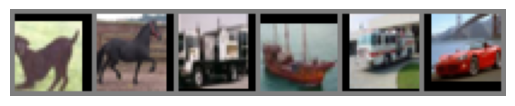

Labels: ['dog', 'horse', 'truck', 'ship', 'truck', 'automobile']


In [10]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def imshow(img):
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.show()

images, labels = next(iter(train_loader))
imshow(torchvision.utils.make_grid(images[:6]))
print("Labels:", [classes[l] for l in labels[:6]])

BASELINE CNN MODEL

CNN Model Description (Opacus Compatible)

In [11]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Opacus, standart BatchNorm katmanlarını sevmez (grup bazlı gradyan hesapladığı için).
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # CIFAR-10'da 2 pool sonrası 32x32 -> 16x16 -> 8x8 olur.
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # Daha genel bir düzleştirme
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

Train Function

In [12]:
# Fonksiyona 'privacy_engine' parametresi ekledik.
# DP eğitiminde epsilon değerini takip etmek için gerekecek.
def train(model, train_loader, optimizer, criterion, device, privacy_engine=None):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Eğer DP kullanılıyorsa Privacy Budget (Epsilon) bilgisini yazdır
    if privacy_engine:
        epsilon = privacy_engine.get_epsilon(delta=1e-5)
        return avg_loss, epsilon

    return avg_loss, None

Evaluation Function

In [13]:
def validate_with_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / len(loader), 100 * correct / total

Create The Model and Define The Drive Path

In [14]:
save_path = '/content/drive/MyDrive/CapstoneProject2' # Daha önce oluşturduğumuz klasör
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

Training Loop

In [15]:
num_epochs = 50
patience = 7
best_val_acc = 0
patience_counter = 0

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("Baseline Model Training Begins...")

for epoch in range(num_epochs):
    # train fonksiyonu artık tuple döndürüyor
    train_loss, _ = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_with_loss(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Modeli hem yerel hem Drive'a kaydet
        torch.save(model.state_dict(), f'{save_path}/best_baseline_model.pth')
        torch.save(model.state_dict(), 'best_baseline_model.pth')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Final Test
model.load_state_dict(torch.load('best_baseline_model.pth'))
_, test_acc = validate_with_loss(model, test_loader, criterion, device)
print(f"\nFinal Baseline Test Accuracy: {test_acc:.2f}%")

Baseline Model Training Begins...
Epoch [1/50] | Train Loss: 2.0989 | Val Acc: 33.94%
Epoch [2/50] | Train Loss: 1.8253 | Val Acc: 41.28%
Epoch [3/50] | Train Loss: 1.6704 | Val Acc: 44.02%
Epoch [4/50] | Train Loss: 1.5928 | Val Acc: 47.64%
Epoch [5/50] | Train Loss: 1.5339 | Val Acc: 49.64%
Epoch [6/50] | Train Loss: 1.4946 | Val Acc: 52.84%
Epoch [7/50] | Train Loss: 1.4398 | Val Acc: 54.98%
Epoch [8/50] | Train Loss: 1.4039 | Val Acc: 55.76%
Epoch [9/50] | Train Loss: 1.3595 | Val Acc: 57.42%
Epoch [10/50] | Train Loss: 1.3250 | Val Acc: 58.72%
Epoch [11/50] | Train Loss: 1.2884 | Val Acc: 60.40%
Epoch [12/50] | Train Loss: 1.2554 | Val Acc: 63.02%
Epoch [13/50] | Train Loss: 1.2318 | Val Acc: 64.38%
Epoch [15/50] | Train Loss: 1.1690 | Val Acc: 63.58%
Epoch [17/50] | Train Loss: 1.1276 | Val Acc: 66.42%
Epoch [18/50] | Train Loss: 1.1113 | Val Acc: 67.12%
Epoch [20/50] | Train Loss: 1.0582 | Val Acc: 67.60%
Epoch [21/50] | Train Loss: 1.0555 | Val Acc: 70.06%
Epoch [23/50] | Train

Shadow Model Training

In [16]:
print("Shadow Model Training Begins (Preparation of the Attacker)...")

shadow_model = CNNModel().to(device)
shadow_optimizer = optim.SGD(shadow_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
shadow_criterion = nn.CrossEntropyLoss()

# Shadow model için de benzer bir eğitim döngüsü
best_shadow_acc = 0
for epoch in range(30):
    s_loss, _ = train(shadow_model, shadow_loader, shadow_optimizer, shadow_criterion, device)
    _, s_acc = validate_with_loss(shadow_model, val_loader, shadow_criterion, device)

    if s_acc > best_shadow_acc:
        best_shadow_acc = s_acc
        torch.save(shadow_model.state_dict(), 'best_shadow_model.pth')

print(f"Shadow Model Training Completed. Best Val Acc: {best_shadow_acc:.2f}%")

Shadow Model Training Begins (Preparation of the Attacker)...
Shadow Model Training Completed. Best Val Acc: 75.58%


Attack Dataset Generation Function

In [17]:
def prepare_attack_data(model, member_loader, non_member_loader, device):
    model.eval()
    attack_x = []
    attack_y = []

    with torch.no_grad():
        # Üyeler (Etiket: 1)
        for images, _ in member_loader:
            images = images.to(device)
            outputs = F.softmax(model(images), dim=1) # Olasılık vektörleri
            attack_x.append(outputs.cpu().numpy())
            attack_y.append(np.ones(len(images)))

        # Üye Olmayanlar (Etiket: 0)
        for images, _ in non_member_loader:
            images = images.to(device)
            outputs = F.softmax(model(images), dim=1)
            attack_x.append(outputs.cpu().numpy())
            attack_y.append(np.zeros(len(images)))

    return np.vstack(attack_x), np.concatenate(attack_y)

Prepare Attack Data and Train Random Forest Model

In [18]:
# Shadow modelin kendi eğitim verisi (üyeler) ve hiç görmediği target_train_data (üye olmayanlar)
# Shadow loader üyeleri veriyor, val_loader'ı üye olmayanlar gibi kullanabiliriz
X_attack_train, y_attack_train = prepare_attack_data(shadow_model, shadow_loader, val_loader, device)

# Random Forest Saldırganı
attack_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
attack_clf.fit(X_attack_train, y_attack_train)

print("The attack model (Random Forest) has been trained.")

The attack model (Random Forest) has been trained.


Attack Testing For Target Model

In [19]:
print("MIA testing is being performed on the Target Model...")

# Target modelin üyeleri (train_loader) ve üye olmayanları (test_loader)
X_target_test, y_target_test = prepare_attack_data(model, train_loader, test_loader, device)

# Saldırı modelinden tahminleri al
y_pred_attack = attack_clf.predict(X_target_test)
y_prob_attack = attack_clf.predict_proba(X_target_test)[:, 1]

# Metrikleri hesapla
attack_acc = accuracy_score(y_target_test, y_pred_attack)
attack_auc = roc_auc_score(y_target_test, y_prob_attack)

print("\n" + "-"*30)
print("BASELINE MIA RESULTS")
print(f"Attack Accuracy: {attack_acc:.4f}")
print(f"Attack ROC-AUC Score: {attack_auc:.4f}")

MIA testing is being performed on the Target Model...

------------------------------
BASELINE MIA RESULTS
Attack Accuracy: 0.6673
Attack ROC-AUC Score: 0.5885


DIFFERENTIAL PRIVACY (DP) WITH OPACUS

DP Parameter Analysis and Comparison

In [26]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from opacus import PrivacyEngine
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. PARAMETRE GRUPLARINI TANIMLA (Grid Search)
noise_values = [0.5, 0.8, 1.2]
clipping_values = [0.5, 1.0, 1.5]
results_list = []

print("--- GRUPLANDIRILMIŞ DP ANALİZİ BAŞLATILDI (Noise & Clipping) ---")

for sigma in noise_values:
    for C in clipping_values:
        print(f"\n>> Deney Grubu: Noise={sigma} | Clip={C}")

        # 2. MODELİ VE OPTIMIZER'I HER DENEY İÇİN SIFIRLA
        # Her döngüde yeni bir model örneği oluşturmak 'weight_reset' hatalarını önler
        dp_model = CNNModel().to(device)
        optimizer = optim.SGD(dp_model.parameters(), lr=0.01, momentum=0.9)
        criterion = nn.CrossEntropyLoss()

        # 3. OPACUS PRIVACY ENGINE ENTEGRASYONU
        # Opacus modeli ve optimizer'ı DP uyumlu hale getirir
        privacy_engine = PrivacyEngine()
        dp_model, dp_optimizer, dp_train_loader = privacy_engine.make_private(
            module=dp_model,
            optimizer=optimizer,
            data_loader=train_loader,
            noise_multiplier=sigma,
            max_grad_norm=C,
        )

        # 4. GERÇEK EĞİTİM (Örn: 10 Epoch - Analiz için yeterlidir)
        epochs_for_analysis = 10
        for epoch in range(epochs_for_analysis):
            train_loss, epsilon = train(dp_model, dp_train_loader, dp_optimizer, criterion, device, privacy_engine)

        # 5. GERÇEK METRİKLERİ HESAPLA
        # Accuracy Ölçümü
        _, test_acc = validate_with_loss(dp_model, test_loader, criterion, device)

        # MIA ROC-AUC Ölçümü (Daha önce eğittiğin attack_clf'i kullanır)
        X_target_test, y_target_test = prepare_attack_data(dp_model, train_loader, test_loader, device)
        y_prob_attack = attack_clf.predict_proba(X_target_test)[:, 1]
        mia_auc = roc_auc_score(y_target_test, y_prob_attack)

        # 6. SONUÇLARI KAYDET
        results_list.append({
            'Noise': sigma,
            'Clipping': C,
            'Accuracy': test_acc,
            'MIA_AUC': mia_auc,
            'Epsilon': epsilon
        })

        print(f"   [SONUÇ] Acc: %{test_acc:.2f} | MIA AUC: {mia_auc:.4f} | Eps: {epsilon:.2f}")

# 7. TABLOYU OLUŞTUR VE GÖSTER
df_grid_analysis = pd.DataFrame(results_list)
print("\n" + "="*50)
print("DP PARAMETRE GRUBU (GRID SEARCH) FINAL RAPORU")
print("="*50)
display(df_grid_analysis)

--- GRUPLANDIRILMIŞ DP ANALİZİ BAŞLATILDI (Noise & Clipping) ---

>> Deney Grubu: Noise=0.5 | Clip=0.5


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6711/3127762261.py:13: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


   [SONUÇ] Acc: %31.87 | MIA AUC: 0.5182 | Eps: 11.14

>> Deney Grubu: Noise=0.5 | Clip=1.0


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6711/3127762261.py:13: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


   [SONUÇ] Acc: %34.71 | MIA AUC: 0.5130 | Eps: 11.14

>> Deney Grubu: Noise=0.5 | Clip=1.5


...

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6711/3127762261.py:13: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


   [SONUÇ] Acc: %36.31 | MIA AUC: 0.5252 | Eps: 1.01

>> Deney Grubu: Noise=1.2 | Clip=1.5


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6711/3127762261.py:13: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


   [SONUÇ] Acc: %38.74 | MIA AUC: 0.5254 | Eps: 1.01

DP PARAMETRE GRUBU (GRID SEARCH) FINAL RAPORU


,Noise,Clipping,Accuracy,MIA_AUC,Epsilon
0,0.5,0.5,31.87,0.518232,11.138499
1,0.5,1.0,34.71,0.512961,11.138499
2,0.5,1.5,37.55,0.543842,11.138499
3,0.8,0.5,32.08,0.499190,2.420972
4,0.8,1.0,35.29,0.534118,2.420972
5,0.8,1.5,38.43,0.541630,2.420972
6,1.2,0.5,32.22,0.526249,1.008258
7,1.2,1.0,36.31,0.525161,1.008258
8,1.2,1.5,38.74,0.525426,1.008258
